# Bulk RNA-seq mapping with kb-python

This notebook demonstrates an **alignment-free bulk RNA-seq workflow** in **OmicVerse** using **kb-python (kallisto | bustools)**, starting from SRA files and ending with **differential expression (DE)** and visualization.

**Pipeline overview**

1. Import OmicVerse and set plotting style  
2. Download SRA data (direct `.lite.1` links)  
3. Convert SRA → paired FASTQ (`parallel_fastq_dump`)  
4. Download reference genome/annotation (Ensembl GRCh38)  
5. Build kb reference (index + transcript-to-gene map)  
6. Quantify reads with kb-python (`ov.alignment.count`, technology=`BULK`)  
7. Merge samples into a single matrix and run DESeq2 via `ov.bulk.pyDEG`  
8. Visualize DEGs (volcano)

▲ **CRITICAL** This notebook **does not modify any existing code or outputs**; it only adds tutorial-style Markdown explanations around the provided cells.


## Step 0 — Import OmicVerse

We start by importing OmicVerse and setting a consistent plotting style for downstream figures.


In [2]:
%%time
import omicverse as ov
ov.style(font_path='Arial')

🔬 Starting plot initialization...
Using already downloaded Arial font from: /tmp/omicverse_arial.ttf
Registered as: Arial
🧬 Detecting GPU devices…
✅ NVIDIA CUDA GPUs detected: 1
    • [CUDA 0] Tesla P40
      Memory: 22.4 GB | Compute: 6.1

   ____            _     _    __                  
  / __ \____ ___  (_)___| |  / /__  _____________ 
 / / / / __ `__ \/ / ___/ | / / _ \/ ___/ ___/ _ \ 
/ /_/ / / / / / / / /__ | |/ /  __/ /  (__  )  __/ 
\____/_/ /_/ /_/_/\___/ |___/\___/_/  /____/\___/                                              

🔖 Version: 1.7.9rc1   📚 Tutorials: https://omicverse.readthedocs.io/
✅ plot_set complete.

CPU times: user 7.88 s, sys: 2.53 s, total: 10.4 s
Wall time: 15.3 s


## Step 1 — Download SRA inputs (direct `.lite.1` links)

Here we download several example SRA runs. In this workflow, we use **direct NCBI SRA download links** ending with `.lite.1`.

▲ **CRITICAL**
- `ov.datasets.download_data(..., dir=...)` will skip downloads if the file already exists.
- In many environments, you can also download via `ov.alignment.prefetch()` and then convert using `fastq-dump`/`fasterq-dump`.
- If your network blocks direct SRA links, switch to `prefetch` or mirror the files to a reachable location.


In [7]:
links=[
    'https://sra-downloadb.be-md.ncbi.nlm.nih.gov/sos9/sra-pub-zq-922/SRR012/12544/SRR12544419/SRR12544419.lite.1',#no
    'https://sra-downloadb.be-md.ncbi.nlm.nih.gov/sos9/sra-pub-zq-924/SRR012/12544/SRR12544421/SRR12544421.lite.1',#no
    'https://sra-downloadb.be-md.ncbi.nlm.nih.gov/sos9/sra-pub-zq-922/SRR012/12544/SRR12544433/SRR12544433.lite.1'#yes
    'https://sra-downloadb.be-md.ncbi.nlm.nih.gov/sos9/sra-pub-zq-922/SRR012/12544/SRR12544435/SRR12544435.lite.1'#yes
]
for link in links:
    ov.datasets.download_data(link,dir='./data')

🔍 Downloading data to ./data/SRR12544433.lite.1


Downloading: 100%|█████████▉| 426M/426M [00:12<00:00, 34.0MB/s] 

✅ Download completed


## Step 2 — Convert SRA → paired FASTQ (single example)

This cell shows converting **one** SRA file into **paired FASTQ** using `ov.alignment.parallel_fastq_dump`.

▲ **CRITICAL**
- Set `split_files=True` for paired-end output (`*_1.fastq.gz`, `*_2.fastq.gz`).
- Use a fast local disk for `tmpdir` to reduce I/O overhead.
- Thread count controls conversion speed; choose based on your CPU allocation.


In [2]:
ov.alignment.parallel_fastq_dump(
    sra_id='./data/SRR12544421.lite.1',
    threads=12,
    outdir='./data/SRR12544421',
    tmpdir='./tmp',
    split_files=True,
    gzip=True,
)

🚀 Starting parallel-fastq-dump for ./data/SRR12544421.lite.1
    Threads: 12
    Output directory: ./data/SRR12544421
    Added to PATH: /home/groups/xiaojie/steorra/env/omicverse/bin
>> /home/groups/xiaojie/steorra/env/omicverse/bin/parallel-fastq-dump --sra-id ./data/SRR12544421.lite.1 --threads 12 --outdir ./data/SRR12544421 --tmpdir ./tmp --minSpotId 1 --split-files --gzip
2026-01-29 23:56:27,879 - SRR ids: ['./data/SRR12544421.lite.1']
2026-01-29 23:56:27,879 - extra args: ['--split-files', '--gzip']
2026-01-29 23:56:27,880 - tempdir: ./tmp/pfd_0armgw5l
2026-01-29 23:56:27,880 - CMD: sra-stat --meta --quick ./data/SRR12544421.lite.1
2026-01-29 23:56:27,982 - ./data/SRR12544421.lite.1 spots: 10963094
2026-01-29 23:56:27,982 - blocks: [[1, 913591], [913592, 1827182], [1827183, 2740773], [2740774, 3654364], [3654365, 4567955], [4567956, 5481546], [5481547, 6395137], [6395138, 7308728], [7308729, 8222319], [8222320, 9135910], [9135911, 10049501], [10049502, 10963094]]
2026-01-29 23:56

{'sra_id': './data/SRR12544421.lite.1',
 'threads': 12,
 'outdir': './data/SRR12544421',
 'split_files': True,
 'gzip': True}

## Step 2b — Batch conversion for multiple SRAs

This loop converts multiple SRA files to paired FASTQs using the same settings.

Tip: If you have many samples, consider using a job scheduler (e.g., Slurm) to parallelize across nodes rather than increasing threads indefinitely on one node.


In [3]:
for sra in [
    'SRR12544433','SRR12544435'
]:
    ov.alignment.parallel_fastq_dump(
        sra_id=f'./data/{sra}.lite.1',
        threads=12,
        outdir=f'./data/{sra}',
        tmpdir='./tmp',
        split_files=True,
        gzip=True,
    )

🚀 Starting parallel-fastq-dump for ./data/SRR12544433.lite.1
    Threads: 12
    Output directory: ./data/SRR12544433
    Added to PATH: /home/groups/xiaojie/steorra/env/omicverse/bin
>> /home/groups/xiaojie/steorra/env/omicverse/bin/parallel-fastq-dump --sra-id ./data/SRR12544433.lite.1 --threads 12 --outdir ./data/SRR12544433 --tmpdir ./tmp --minSpotId 1 --split-files --gzip
2026-01-29 23:58:48,245 - SRR ids: ['./data/SRR12544433.lite.1']
2026-01-29 23:58:48,245 - extra args: ['--split-files', '--gzip']
2026-01-29 23:58:48,246 - tempdir: ./tmp/pfd_8tgtda45
2026-01-29 23:58:48,246 - CMD: sra-stat --meta --quick ./data/SRR12544433.lite.1
2026-01-29 23:58:48,358 - ./data/SRR12544433.lite.1 spots: 16602881
2026-01-29 23:58:48,358 - blocks: [[1, 1383573], [1383574, 2767146], [2767147, 4150719], [4150720, 5534292], [5534293, 6917865], [6917866, 8301438], [8301439, 9685011], [9685012, 11068584], [11068585, 12452157], [12452158, 13835730], [13835731, 15219303], [15219304, 16602881]]
2026-01-

## Step 3 — Download reference genome + annotation

We download **GRCh38** reference FASTA and **GTF** from Ensembl.

▲ **CRITICAL**
- Keep the FASTA and GTF from the **same Ensembl release** to avoid mismatches in transcript IDs.
- Ensure enough disk space (human reference files are large).


In [68]:
ov.datasets.download_data('ftp://ftp.ensembl.org/pub/release-108/fasta/homo_sapiens/dna/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz',
                         dir='./genomes')
ov.datasets.download_data('ftp://ftp.ensembl.org/pub/release-108/gtf/homo_sapiens/Homo_sapiens.GRCh38.108.gtf.gz',
                         dir='./genomes')

🔍 Downloading data to ./genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz



Downloading: 100%|█████████▉| 881M/881M [00:14<00:00, 60.9MB/s]  

✅ Download completed
🔍 Downloading data to ./genomes/Homo_sapiens.GRCh38.108.gtf.gz


Downloading: 100%|█████████▉| 54.1M/54.1M [00:03<00:00, 17.5MB/s]

✅ Download completed


'./genomes/Homo_sapiens.GRCh38.108.gtf.gz'

## Step 4 — Build kb-python reference (index + t2g + cDNA)

`ov.alignment.single.ref(...)` prepares the kb-python reference assets:

- `index.idx`: kallisto index
- `t2g.txt`: transcript-to-gene mapping used to aggregate counts to genes
- `cdna.fa`: transcriptome FASTA derived from the annotation

▲ **CRITICAL**
- The first build can be time-consuming; once built, reuse the same outputs for all samples.
- Place the index on fast storage to speed up quantification.


In [43]:
result = ov.alignment.single.ref(
    fasta_paths='genomes/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz',  #input
    gtf_paths='genomes/Homo_sapiens.GRCh38.108.gtf.gz', #input
    index_path='pbmc_1k_v3/index.idx', #output
    t2g_path='pbmc_1k_v3/t2g.txt', #output
    cdna_path='pbmc_1k_v3/cdna.fa', #output
    temp_dir='tmp',
    overwrite=True,
)
print(result.keys())

🚀 Starting ref workflow: standard
    Using temporary directory: tmp-kb-e9513f2c23aa46d1961cde1d7afeba6b
>> /home/groups/xiaojie/steorra/env/omicverse/bin/kb ref --tmp tmp-kb-e9513f2c23aa46d1961cde1d7afeba6b -i pbmc_1k_v3/index.idx -g pbmc_1k_v3/t2g.txt -t 8 --overwrite --d-list-overhang 1 -f1 pbmc_1k_v3/cdna.fa pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz
[2026-01-29 22:21:41,856]    INFO [ref] Preparing pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz, pbmc_1k_v3/Homo_sapiens.GRCh38.108.gtf.gz
[2026-01-29 22:22:33,317]    INFO [ref] Splitting genome pbmc_1k_v3/Homo_sapiens.GRCh38.dna.primary_assembly.fa.gz into cDNA at /scratch/users/steorra/analysis/26_omic_protocol/tmp-kb-e9513f2c23aa46d1961cde1d7afeba6b/tmpoyd3o7ta
[2026-01-29 22:23:30,907]    INFO [ref] Concatenating 1 cDNAs to pbmc_1k_v3/cdna.fa
[2026-01-29 22:23:31,551]    INFO [ref] Creating transcript-to-gene mapping at pbmc_1k_v3/t2g.txt
[2026-01-29 22:23:33,230

## Step 5 — Quantify one sample with kb-python (technology = `BULK`)

This is an example call for **one** sample.

▲ **CRITICAL**
- For bulk RNA-seq, each sample is treated as one “library” (no barcode filtering).
- `h5ad=True` writes an AnnData object for convenient downstream analysis in OmicVerse/Scanpy.
- If your environment does not expose `count(...)` directly, the equivalent OmicVerse entry point is typically `ov.alignment.count(...)` (the rest of the arguments stay the same).


In [50]:
result = count(
    fastq_paths=[
        "./data/SRR12544419/SRR12544419.lite.1_1.fastq.gz", 
        "./data/SRR12544419/SRR12544419.lite.1_2.fastq.gz",
    ],
    index_path="pbmc_1k_v3/index.idx",
    t2g_path="pbmc_1k_v3/t2g.txt",
    technology='BULK', # technology
    output_path="results/pbmc_test",
    h5ad=True,
    filter_barcodes=False,
    threads=12,
    parity="paired",          # 
    strand="unstranded",      # 
)
print(result.keys())

🚀 Starting count workflow: standard
    Technology: BULK
    Output directory: .
    Using temporary directory: tmp-kb-6e8cfea103a042e79f4e83e5bd1facf2
>> /home/groups/xiaojie/steorra/env/omicverse/bin/kb count --tmp tmp-kb-6e8cfea103a042e79f4e83e5bd1facf2 -i pbmc_1k_v3/index.idx -g pbmc_1k_v3/t2g.txt -x BULK -o . -t 12 -m 2G --h5ad --parity paired --strand unstranded ./data/SRR12544419/SRR12544419.lite.1_1.fastq.gz ./data/SRR12544419/SRR12544419.lite.1_2.fastq.gz
[2026-01-29 22:53:46,113]    INFO [count] Using index pbmc_1k_v3/index.idx to generate BUS file to . from
[2026-01-29 22:53:46,113]    INFO [count]         ./data/SRR12544419/SRR12544419.lite.1_1.fastq.gz
[2026-01-29 22:53:46,113]    INFO [count]         ./data/SRR12544419/SRR12544419.lite.1_2.fastq.gz
[2026-01-29 22:54:23,070]    INFO [count] Sorting BUS file ./output.bus to tmp-kb-6e8cfea103a042e79f4e83e5bd1facf2/output.s.bus
[2026-01-29 22:54:25,476]    INFO [count] Inspecting BUS file tmp-kb-6e8cfea103a042e79f4e83e5bd1fac

## Step 5b — Quantify all samples (loop)

We run kb-python quantification for each sample and save results into per-sample output folders.

Tip: In practice, you may want to set a clear naming convention for `output_path` (project/sample/date) to keep results reproducible.


In [5]:
for sra in [
    'SRR12544419','SRR12544421','SRR12544433','SRR12544435'
]:
    result = ov.alignment.count(
        fastq_paths=[
            f"./data/{sra}/{sra}.lite.1_1.fastq.gz", 
            f"./data/{sra}/{sra}.lite.1_2.fastq.gz",
        ],
        index_path="pbmc_1k_v3/index.idx",
        t2g_path="pbmc_1k_v3/t2g.txt",
        technology='BULK', # technology
        output_path=f"results/{sra}/",
        h5ad=True,
        filter_barcodes=False,
        threads=12,
        parity="paired",          # ✅关键
        strand="unstranded",      # ✅建议显式写
    )
    print(result.keys())

🚀 Starting count workflow: standard
    Technology: BULK
    Output directory: results/SRR12544419/
    Using temporary directory: tmp-kb-36a26e9c1a61444387dc9ef0c9f177dc
>> /home/groups/xiaojie/steorra/env/omicverse/bin/kb count --tmp tmp-kb-36a26e9c1a61444387dc9ef0c9f177dc -i pbmc_1k_v3/index.idx -g pbmc_1k_v3/t2g.txt -x BULK -o results/SRR12544419/ -t 12 -m 2G --h5ad --parity paired --strand unstranded ./data/SRR12544419/SRR12544419.lite.1_1.fastq.gz ./data/SRR12544419/SRR12544419.lite.1_2.fastq.gz
[2026-01-30 00:03:00,630]    INFO [count] Using index pbmc_1k_v3/index.idx to generate BUS file to results/SRR12544419/ from
[2026-01-30 00:03:00,630]    INFO [count]         ./data/SRR12544419/SRR12544419.lite.1_1.fastq.gz
[2026-01-30 00:03:00,630]    INFO [count]         ./data/SRR12544419/SRR12544419.lite.1_2.fastq.gz
[2026-01-30 00:03:35,180]    INFO [count] Sorting BUS file results/SRR12544419/output.bus to tmp-kb-36a26e9c1a61444387dc9ef0c9f177dc/output.s.bus
[2026-01-30 00:03:37,594

## Step 6 — Load per-sample results and harmonize gene identifiers

Each kb-python run generates an `adata.h5ad` plus companion gene name files.
We load per-sample AnnData objects and ensure `adata.var` contains both:

- `gene_name`
- `gene_id`

▲ **CRITICAL**
Gene naming conventions can differ across pipelines; explicitly setting `adata.var['gene_name']` and using it as index makes downstream merging and visualization more robust.


In [11]:
ad_dict={}
for sra in [
    'SRR12544419','SRR12544421','SRR12544433','SRR12544435'
]:
    ad=ov.read(f'./results/{sra}/counts_unfiltered/adata.h5ad')
    gene_name=ov.pd.read_csv(
        f'./results/{sra}/counts_unfiltered/cells_x_genes.genes.names.txt',
        header=None
    )
    ad.var['gene_name']=gene_name[0].tolist()
    ad.var['gene_id']=ad.var.index
    ad.var.index=ad.var['gene_name']
    ad.var_names_make_unique()
    ad.obs['sra']=sra
    ad_dict[sra]=ad

## Step 7 — Merge samples and define phenotype labels

We concatenate all samples into one `AnnData` and create a `Group` column (e.g., disease vs healthy) for downstream DE.

▲ **CRITICAL**
For bulk RNA-seq, you typically want one observation per **sample**. In this demo workflow, each sample’s output is concatenated and then labeled via `adata.obs['Group']`.


In [14]:
adata=ov.concat(ad_dict)
adata.obs_names_make_unique()
adata.obs['Group']=['no','no','yes','yes']
adata

AnnData object with n_obs × n_vars = 4 × 62703
    obs: 'sra', 'Group'

## Step 7b — Quick sanity check (gene expression)

A quick check on a marker gene can help confirm that the matrix was loaded correctly and contains non-zero counts where expected.


In [15]:
adata[:,'CD3D'].X.toarray()

array([[623.],
       [612.],
       [ 98.],
       [324.]])

## Step 8 — Convert to a count matrix for DE

`ov.bulk.pyDEG` expects a **gene × sample** count matrix (pandas DataFrame).
Here we convert AnnData to a DataFrame and transpose to match that convention.

▲ **CRITICAL**
DESeq2-style methods require **raw integer counts**. Do not apply log-normalization before DESeq2.


In [17]:
data=adata.to_df().T
data.head()

barcode,AAAAAAAAAAAAAAAA,AAAAAAAAAAAAAAAA-1,AAAAAAAAAAAAAAAA-2,AAAAAAAAAAAAAAAA-3
gene_name,,,,
ATAD3B,90.0,70.0,30.0,115.0
DDX11L17,4.0,0.0,0.0,0.0
ENSG00000228037.1,9.0,8.0,1.0,8.0
PRDM16,0.0,0.0,0.0,0.0
ENSG00000284616.1,0.0,0.0,0.0,0.0


## Step 9 — Create a `pyDEG` object

We wrap the count matrix into an OmicVerse `pyDEG` object for differential expression analysis.


In [18]:
dds=ov.bulk.pyDEG(data)

## Step 10 — Differential expression (DESeq2)

We run DE analysis using the **DESeq2** backend.

▲ **CRITICAL**
- DESeq2 expects raw integer counts and internally estimates size factors/dispersion.
- The `treatment_groups` and `control_groups` here refer to the **column/sample identifiers** in the provided matrix. In your own data, replace them with the appropriate sample IDs (often the sample names).


In [19]:
dds.drop_duplicates_index()
print('... drop_duplicates_index success')
treatment_groups=['AAAAAAAAAAAAAAAA-2','AAAAAAAAAAAAAAAA-3']
control_groups=['AAAAAAAAAAAAAAAA','AAAAAAAAAAAAAAAA-1']
result=dds.deg_analysis(treatment_groups,control_groups,method='DEseq2')


... drop_duplicates_index success
⚙️ You are using DEseq2 method for differential expression analysis.
⏰ Start to create DeseqDataSet...


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 1.55 seconds.

Fitting dispersion trend curve...
... done in 0.41 seconds.

Fitting MAP dispersions...


logres_prior=1.2473932639674563, sigma_prior=0.25


... done in 1.99 seconds.

Fitting LFCs...
... done in 1.79 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: condition Treatment vs Control
                        baseMean  log2FoldChange     lfcSE      stat  \
gene_name                                                              
B2M                178491.812733        0.065096  0.418607  0.155506   
S100A9             170557.796728        0.378402  0.248436  1.523133   
S100A8             154015.888583        0.914504  0.455013  2.009840   
MT-RNR2            143254.671256        0.434606  0.553576  0.785089   
HBB                127090.703257        2.661912  1.449787  1.836071   
...                          ...             ...       ...       ...   
ENSG00000273937.1       0.000000             NaN       NaN       NaN   
ENSG00000278633.1       0.000000             NaN       NaN       NaN   
ENSG00000278066.1       0.000000             NaN       NaN       NaN   
ENSG00000277374.1       0.000000             NaN       NaN       NaN   
ENSG00000275661.1       0.000000             NaN       NaN       Na

... done in 23.00 seconds.



## Step 11 — Filter low-expression genes

Filtering removes genes with insufficient signal and can improve interpretability and multiple-testing behavior.

Here we apply a `BaseMean` threshold after DE is computed.


In [21]:
print(result.shape)
result=result.loc[result['log2(BaseMean)']>1]
print(result.shape)

(21002, 14)
(21002, 14)


## Step 12 — Set DEG thresholds

We set thresholds for significance and fold-change, which control DEG calling and downstream visualization.


In [22]:
# -1 means automatically calculates
dds.foldchange_set(fc_threshold=-1,
                   pval_threshold=0.05,
                   logp_max=10)

... Fold change threshold: 2.9757964388302165


## Step 13 — Visualize DEGs (volcano plot)

A volcano plot summarizes effect size (log2FC) vs significance.

Tip: After identifying DEGs, typical next steps include:
- Gene set enrichment (GO/KEGG/Reactome)
- Pathway visualization
- PPI network analysis

(Those downstream steps can be added as additional sections depending on your tutorial scope.)


🌋 Volcano Plot Analysis:
   Total genes: 62703
   ↗️  Upregulated genes: 56
   ↘️  Downregulated genes: 39
   ➡️  Non-significant genes: 62608
   🎯 Total significant genes: 95
   log2FC range: -10.26 to 10.10
   qvalue range: 5.94e-14 to 1.00e+00

⚙️  Current Function Parameters:
   Data columns: pval_name='qvalue', fc_name='log2FC'
   Thresholds: pval_threshold=0.05, fc_max=2.9757964388302165, fc_min=-2.9757964388302165
   Plot size: figsize=(4, 4)
   Gene labels: plot_genes_num=8, plot_genes_fontsize=12
   Custom genes: None (auto-select top genes)

💡 Parameter Optimization Suggestions:
   ✅ Current parameters are optimal for your data!
────────────────────────────────────────────────────────────


<Axes: title={'center': 'DEG Analysis'}, xlabel='$log_{2}FC$', ylabel='$-log_{10}(qvalue)$'>

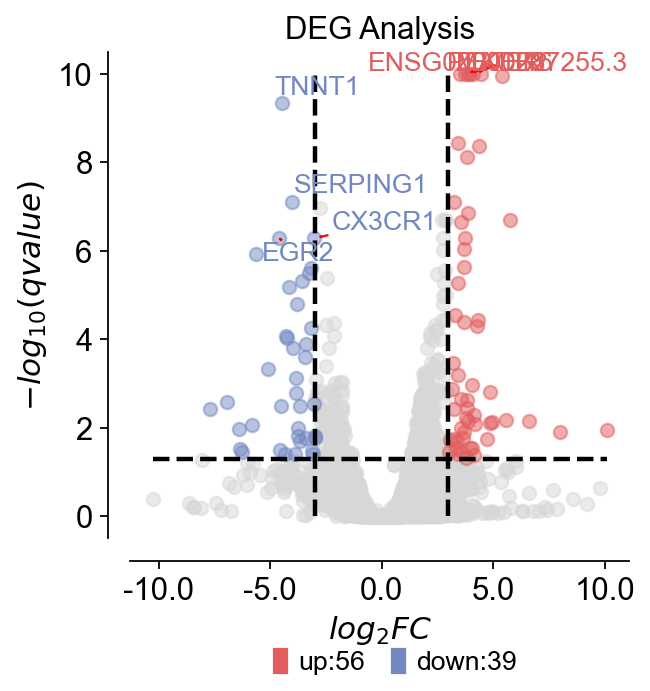

In [23]:
dds.plot_volcano(title='DEG Analysis',figsize=(4,4),
                 plot_genes_num=8,plot_genes_fontsize=12,)

---

## Notes on scaling and reproducibility

- **CPU & memory:** kb-python is usually lighter than full-genome alignment, but index building and quantification still benefit from multiple threads and fast disk.
- **Reference consistency:** Always keep FASTA/GTF release versions consistent (and document the release in your tutorial).
- **Project structure:** Consider organizing outputs as `results/<project>/<sample>/...` and saving a `metadata.csv` describing groups/replicates.

If you want, I can extend this notebook by **adding new Markdown + new code cells** for enrichment and PPI analysis (without touching existing cells), following the same OmicVerse tutorial style.
